# Basic Simulation 参数敏感性验证（raw-interval） / Parameter Sensitivity Validation (raw-interval)

本 Notebook 用于验证模型在不同 `--raw-interval` 下的行为变化。  
This notebook validates how the model behavior changes under different `--raw-interval` settings.

- 固定命令模板：`PYTHONPATH=. python3 examples/basic_simulation.py --hours 8 --raw-interval <value>`  
  Fixed command template: `PYTHONPATH=. python3 examples/basic_simulation.py --hours 8 --raw-interval <value>`
- 扫描范围：`6` 到 `1200`（秒） / Sweep range: `6` to `1200` (seconds)
- 主要观察指标 / Key metrics:
  - `WIP`：`system_metrics.wip_current`
  - `Output`：`system_metrics.throughput_total_units`


In [24]:
from __future__ import annotations

import json
import math
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "examples" / "basic_simulation.py").exists():
    raise RuntimeError("请在仓库根目录执行本 Notebook（需要找到 examples/basic_simulation.py） / Run this notebook from repository root (must find examples/basic_simulation.py)")

# 选取覆盖稀疏与密集补料场景的区间点 / Pick interval points covering sparse to dense replenishment scenarios
RAW_INTERVALS = [6, 10, 15, 20, 30, 45, 60, 90, 120, 180, 300, 450, 600, 900, 1200]
HOURS = 8
LOG_DIR = ROOT / "data" / "logs" / "raw_interval_sweep"
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f"实验点数量 / Number of experiment points: {len(RAW_INTERVALS)}")
print(f"日志输出目录 / Log output directory: {LOG_DIR}")


实验点数量: 15
日志输出目录: /home/admin1/drone-factory-digital-twin-2/data/logs/raw_interval_sweep


In [25]:
def run_one(raw_interval: float, seed: int = 12345, deterministic: bool = True) -> dict:
    """运行一次仿真并返回最终快照指标。 / Run one simulation and return final snapshot metrics."""
    log_path = LOG_DIR / f"basic_simulation_raw_{int(raw_interval)}.jsonl"

    cmd = [
        "python3",
        "examples/basic_simulation.py",
        "--hours",
        str(HOURS),
        "--raw-interval",
        str(raw_interval),
        "--seed",
        str(seed),
        "--log-file",
        str(log_path),
    ]
    if deterministic:
        cmd.append("--deterministic")

    env = os.environ.copy()
    env["PYTHONPATH"] = "."

    completed = subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.returncode != 0:
        raise RuntimeError(
            f"raw_interval={raw_interval} 运行失败 / run failed.\n"
            f"stdout:\n{completed.stdout}\n\n"
            f"stderr:\n{completed.stderr}"
        )

    final_perf = None
    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            evt = json.loads(line)
            if evt.get("event_type") == "performance_metric":
                final_perf = evt

    if final_perf is None:
        raise RuntimeError(f"raw_interval={raw_interval} 未找到 performance_metric 快照 / performance_metric snapshot not found")

    sysm = (final_perf.get("details") or {}).get("system_metrics") or {}
    return {
        "raw_interval": raw_interval,
        "wip": sysm.get("wip_current"),
        "output": sysm.get("throughput_total_units"),
        "lead_time_avg_s": sysm.get("lead_time_avg_s"),
        "log_path": str(log_path),
    }


In [16]:
rows = []
for i, raw_interval in enumerate(RAW_INTERVALS, start=1):
    print(f"[{i:02d}/{len(RAW_INTERVALS)}] 运行 / Running raw_interval={raw_interval} ...")
    rows.append(run_one(raw_interval=raw_interval, seed=12345, deterministic=True))

df = pd.DataFrame(rows).sort_values("raw_interval").reset_index(drop=True)
df


[01/15] 运行 raw_interval=6 ...
[02/15] 运行 raw_interval=10 ...
[03/15] 运行 raw_interval=15 ...


KeyboardInterrupt: 

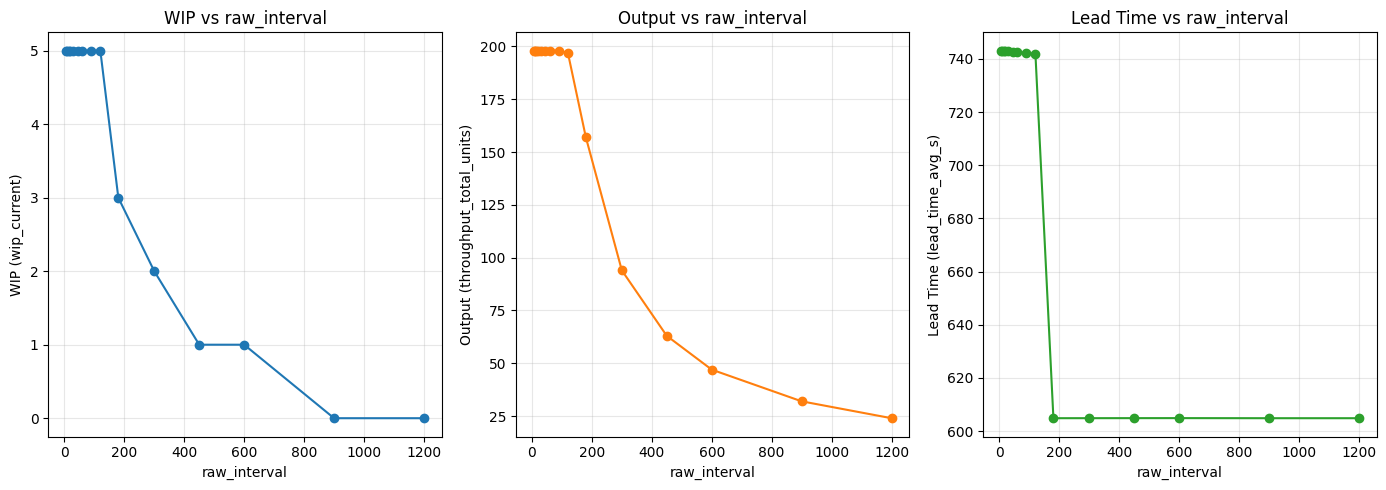

In [26]:

# 修正为 1 行 3 列 / Set to 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# --- 图表 1：WIP / Chart 1: WIP ---
axes[0].plot(df["raw_interval"], df["wip"], marker="o")
axes[0].set_xlabel("raw_interval")
axes[0].set_ylabel("WIP (wip_current)")
axes[0].set_title("WIP vs raw_interval")

axes[0].grid(True, alpha=0.3)

# --- 图表 2：Output / Chart 2: Output ---
axes[1].plot(df["raw_interval"], df["output"], marker="o", color="tab:orange")
axes[1].set_xlabel("raw_interval")
axes[1].set_ylabel("Output (throughput_total_units)")
axes[1].set_title("Output vs raw_interval")

axes[1].grid(True, alpha=0.3)

# --- 图表 3：Lead Time / Chart 3: Lead Time ---
# 更改颜色为 tab:green 以作区分 / Change color to tab:green for distinction
axes[2].plot(df["raw_interval"], df["lead_time_avg_s"], marker="o", color="tab:green")
axes[2].set_xlabel("raw_interval")
axes[2].set_ylabel("Lead Time (lead_time_avg_s)")  # 修正 Y 轴标签 / Fix Y-axis label
axes[2].set_title("Lead Time vs raw_interval")      # 修正标题 / Fix title

axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Worker Configuration Scenario Validation (Scenario 1-4)

本节按你给出的 4 个情景运行 / This section runs the 4 scenarios you provided:
- 3 个装配工位（`DS2/DS3/DS5`）分配初级/熟练工  
  Assign beginner/experienced workers to 3 assembly stations (`DS2/DS3/DS5`)
- 最后一站 `DS6` 固定为高熟练工，质检/返修 2 分钟  
  Keep the final station `DS6` as high-experience worker, with 2-minute QA/rework

情景映射 / Scenario mapping:
- `B` = beginner（12 分钟 / 12 minutes）
- `E` = experienced（2 分钟 / 2 minutes）
- `H` = high-experience（2 分钟 / 2 minutes，仅 `DS6` / DS6 only）

运行后将输出每个情景的 `WIP / Output / Lead Time` 对比。  
After running, the notebook outputs `WIP / Output / Lead Time` comparisons for each scenario.

In [1]:
# ===== 可编辑参数区 / Editable parameters =====
from dataclasses import replace

from src.mock_up.config import config_normal_operation
from src.simulation.simulator import Simulator

VALIDATION_HOURS = 8
VALIDATION_RAW_INTERVAL = 600  # 固定补料节拍，专注比较工人配置 / Fixed replenishment cadence, focus on worker configuration comparison
VALIDATION_SEED = 12345
VALIDATION_TIMESTEP = 0.1
VALIDATION_SNAPSHOT_INTERVAL = 60.0

# 工位映射：3个装配工位 + 最后一站质检/返修工位 / Station mapping: 3 assembly stations + final QA/rework station
PROCESS_STATIONS = [2, 3, 5]
QC_STATION = 6

# 固定节拍（秒） / Fixed durations (seconds)
BEGINNER_TASK_SECONDS = 12 * 60
EXPERIENCED_TASK_SECONDS = 2 * 60
HIGH_EXPERIENCE_QC_SECONDS = 2 * 60

# 4 个情景（与你给出的定义一致） / 4 scenarios (consistent with your definition)
# profile: B=beginner(12min), E=experienced(2min)
ASSEMBLY_CASES = [
    {"name": "scenario_1", "profile": ["B", "E", "E"]},
    {"name": "scenario_2", "profile": ["E", "E", "E"]},
    {"name": "scenario_3", "profile": ["B", "B", "E"]},
    {"name": "scenario_4", "profile": ["B", "B", "B"]},
]

ASSEMBLY_LOG_DIR = ROOT / "data" / "logs" / "assembly_sweep"
ASSEMBLY_LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"场景数量 / Number of scenarios: {len(ASSEMBLY_CASES)}")
print(f"日志目录 / Log directory: {ASSEMBLY_LOG_DIR}")

NameError: name 'ROOT' is not defined

In [ ]:
def _apply_station_profile(sim: Simulator, case: dict) -> None:
    """按情景配置 3 个装配工位与最后质检工位。 / Configure 3 assembly stations and the final QA station by scenario."""
    comps = sim.system.components
    profile = case["profile"]

    for station_id, worker_type in zip(PROCESS_STATIONS, profile):
        ds = comps[f"ds_{station_id}"]
        if worker_type == "B":
            duration_s = BEGINNER_TASK_SECONDS
        elif worker_type == "E":
            duration_s = EXPERIENCED_TASK_SECONDS
        else:
            raise ValueError(f"未知工人类型 / Unknown worker type: {worker_type}")

        ds.assembly_duration_distribution = "deterministic"
        ds.assembly_time_min_seconds = float(duration_s)
        ds.assembly_time_max_seconds = float(duration_s)
        ds.worker_efficiency = 1.0

    # 最后一站：高熟练度质检/返修，固定 2 分钟 / Final station: high-experience QA/rework, fixed 2 minutes
    qc = comps[f"ds_{QC_STATION}"]
    qc.assembly_duration_distribution = "deterministic"
    qc.assembly_time_min_seconds = float(HIGH_EXPERIENCE_QC_SECONDS)
    qc.assembly_time_max_seconds = float(HIGH_EXPERIENCE_QC_SECONDS)
    qc.worker_efficiency = 1.0


def run_one_assembly_case(case: dict) -> dict:
    """运行单个工人配置情景并返回最终指标。 / Run one worker-configuration scenario and return final metrics."""
    log_path = ASSEMBLY_LOG_DIR / f"assembly_{case['name']}.jsonl"

    base = config_normal_operation()
    cfg = replace(
        base,
        seed=int(VALIDATION_SEED),
        duration_hours=float(VALIDATION_HOURS),
        timestep_seconds=float(VALIDATION_TIMESTEP),
        raw_material_batch_interval_seconds=float(VALIDATION_RAW_INTERVAL),
        snapshot_interval_seconds=float(VALIDATION_SNAPSHOT_INTERVAL),
        log_file=str(log_path),
        deterministic=True,
        assembly_use_stochastic_duration=False,
        assembly_duration_distribution="deterministic",
    )

    sim = Simulator(cfg)
    _apply_station_profile(sim, case)
    sim.run()

    logs = sim.logger.get_logs()
    with open(log_path, "w", encoding="utf-8") as fh:
        for event in logs:
            fh.write(json.dumps(event, ensure_ascii=False) + "\n")

    final_perf = None
    for evt in logs:
        if evt.get("event_type") == "performance_metric":
            final_perf = evt

    if final_perf is None:
        raise RuntimeError(f"case={case['name']} 未找到 performance_metric 快照 / performance_metric snapshot not found")

    details = final_perf.get("details") or {}
    sysm = details.get("system_metrics") or {}
    stn = details.get("station_metrics") or {}

    cycle_samples = []
    for sid in PROCESS_STATIONS:
        d = stn.get(f"ds_{sid}") or {}
        v = d.get("actual_cycle_time_avg_s")
        if isinstance(v, (int, float)):
            cycle_samples.append(float(v))
    # 情景层总览：取 3 个装配工位平均 cycle time / Scenario-level overview: average cycle time across 3 assembly stations
    scenario_cycle_time_s = float(np.mean(cycle_samples)) if cycle_samples else None

    profile_str = "-".join(case["profile"])
    return {
        "case": case["name"],
        "profile": profile_str,
        "station_2": case["profile"][0],
        "station_3": case["profile"][1],
        "station_5": case["profile"][2],
        "station_6_qc": "H",
        "cycle_time_s": scenario_cycle_time_s,
        "throughput_units": sysm.get("throughput_total_units"),
        "production_time_s": sysm.get("lead_time_avg_s"),
        "log_path": str(log_path),
    }


assembly_rows = []
for i, case in enumerate(ASSEMBLY_CASES, start=1):
    print(f"[{i:02d}/{len(ASSEMBLY_CASES)}] 运行 / Running {case['name']} profile={case['profile']} ...")
    assembly_rows.append(run_one_assembly_case(case))

assembly_df = pd.DataFrame(assembly_rows)
assembly_df

[01/4] 运行 scenario_1 profile=['B', 'E', 'E'] ...
[02/4] 运行 scenario_2 profile=['E', 'E', 'E'] ...
[03/4] 运行 scenario_3 profile=['B', 'B', 'E'] ...
[04/4] 运行 scenario_4 profile=['B', 'B', 'B'] ...


,case,profile,station_2,station_3,station_5,station_6_qc,cycle_time_s,throughput_units,production_time_s,log_path
0,scenario_1,B-E-E,B,E,E,H,320.1,48,364.85,/home/admin1/drone-factory-digital-twin-2/data...
1,scenario_2,E-E-E,E,E,E,H,120.1,48,214.85,/home/admin1/drone-factory-digital-twin-2/data...
2,scenario_3,B-B-E,B,B,E,H,520.1,48,514.85,/home/admin1/drone-factory-digital-twin-2/data...
3,scenario_4,B-B-B,B,B,B,H,720.1,48,664.85,/home/admin1/drone-factory-digital-twin-2/data...


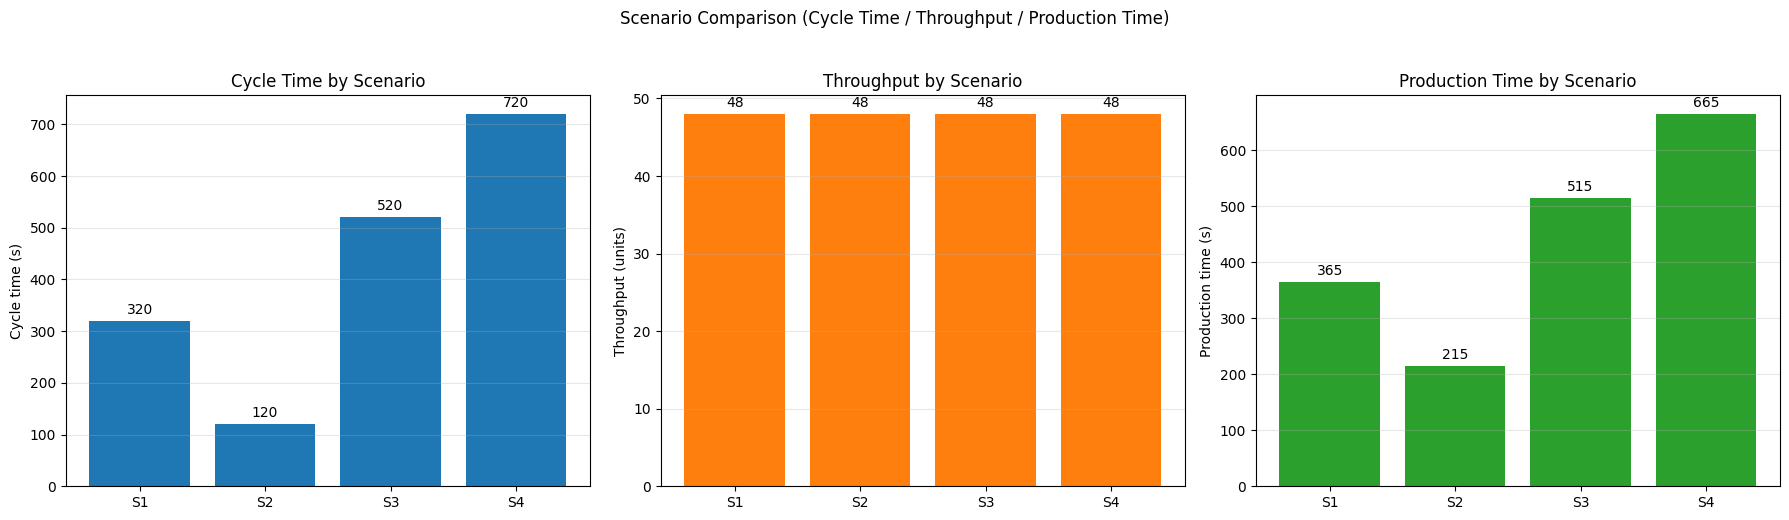

已导出: /home/admin1/drone-factory-digital-twin-2/data/logs/assembly_sweep/assembly_summary_scenarios.csv


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(assembly_df))
labels = assembly_df["case"].tolist()

plot_df = assembly_df.copy()
plot_df["scenario_no"] = (
    plot_df["case"].str.extract(r"(\d+)", expand=False).fillna(plot_df["case"])
)
plot_df["station_profile"] = (
    "DS2:" + plot_df["station_2"]
    + " | DS3:" + plot_df["station_3"]
    + " | DS5:" + plot_df["station_5"]
    + " | DS6:H"
)
plot_df["x_label"] = "S" + plot_df["scenario_no"].astype(str)

bars0 = axes[0].bar(x, plot_df["cycle_time_s"], color="tab:blue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df["x_label"], rotation=0, ha="center")
axes[0].set_ylabel("Cycle time (s)")
axes[0].set_title("Cycle Time by Scenario")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].bar_label(bars0, fmt="%.0f", padding=3)

bars1 = axes[1].bar(x, plot_df["throughput_units"], color="tab:orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["x_label"], rotation=0, ha="center")
axes[1].set_ylabel("Throughput (units)")
axes[1].set_title("Throughput by Scenario")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].bar_label(bars1, fmt="%.0f", padding=3)

bars2 = axes[2].bar(x, plot_df["production_time_s"], color="tab:green")
axes[2].set_xticks(x)
axes[2].set_xticklabels(plot_df["x_label"], rotation=0, ha="center")
axes[2].set_ylabel("Production time (s)")
axes[2].set_title("Production Time by Scenario")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].bar_label(bars2, fmt="%.0f", padding=3)

plt.suptitle("Scenario Comparison (Cycle Time / Throughput / Production Time)", y=1.03)
plt.tight_layout()
plt.show()
